In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner_SGD
import holidays
from simple_strat_funcs import Clean_Implied_Vols_SGD_with_smile
from scipy.stats import norm
from hedging_strategy_class_NEW_KURT_SKEW_vega_VAR import Compare_Trading_Strategies
import seaborn as sns

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This one used log returns for sharpe and uses the domestic rate to compute risk free returns not SOFR like we did prior.

# Global params

In [2]:
train_size = 0.7
test_size = 1 - train_size

TICKER = "USDSGD"

# always use same amount of money in USD to start and convert where necessary
IC_USD = 1_000_000 # initial capital in USD
current_rate = 1.28
IC_SGD = IC_USD * current_rate
NOTIONAL_USD = 1_000_000 # this is used in strategy as our notional to ensure trade positions are in domestic currency

MAX_DELTA_DIFF = 500 # this param doesnt change much as our delta positions are usually much larger
SIGNAL_LB = 0.01
SIGNAL_UB = 0.99
TRANSACTION_COST_BOOL = True
TRANSACTION_COSTS_SPOT = 0.0002 / 2 # for half a leg ie selling/buying once not to enter and exit the trade
TRANSACTION_COSTS_OPTION = 0.0005 / 2 # [change to vol spreads later] for half a leg again, both in decimals

HYPERPARAM_SORT = 'sharpe_ratio' # can be 'sharpe_ratio', 'cagr', 'max_drawdown', 'total_return'
GARCH_1_2_INDICATOR = False

k_bar_MSM = 8
b_MSM = 2.0
gamma_kbar_MSM = 0.5

M = 300 # figarch lags

CONVERT_USD_INDICATOR = True # convert all portfolio values and metrics to USD for fair comparison - use when USD is not domestic

long_threshs = np.array([1.02, 1.03, 1.04, 1.05, 1.06, 1.07,  1.08, 1.09, 1.10, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.20, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27])
short_threshs = np.array([0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92,  0.91, 0.90, 0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.80, 0.79, 0.78, 0.77, 0.76, 0.75, 0.74, 0.73])
sig_multipliers = np.array([1, 3, 5, 7, 9, 11, 13, 15, 17, 20])

# Global data

In [3]:
usdsgd_5m = pd.read_parquet("SGD_USD_5M.parquet").copy()
usdsgd_5m.rename(columns={'c': 'spot'}, inplace=True)  
cleaner_usdsgd = DataCleaner_SGD(usdsgd_5m, start_hr=2, end_hr=18, unit_test=False) 
realised_variance_usdsgd = cleaner_usdsgd.clean_data()
daily_log_returns_usdsgd = pd.read_parquet("DF_D_USDSGD.parquet")['Log_r']
start_date = pd.to_datetime(realised_variance_usdsgd.index.min())
end_date = pd.to_datetime(realised_variance_usdsgd.index.max())
spot_curr = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
overnight_domestic_rate = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SORA_daily.csv").set_index("Date") 
overnight_domestic_rate.index = (pd.to_datetime(overnight_domestic_rate.index, format='mixed').normalize())
overnight_foreign_rate = pd.read_csv("SOFR_daily.csv").set_index("date")

# Global functions

Change holidays where needed. 

In [4]:
def align_spots(df, aligned_df, start, end):

    df = df[(df.index >= start) & (df.index <= end)]

    years = range(start.year, end.year + 1)

    first = holidays.US(years=years)
    second = holidays.Singapore(years=years)

    hols = pd.to_datetime(list(set(first) | set(second))).normalize()

    idx  = df.index
    mask = ~idx.isin(hols)
    new_df = df.loc[mask]

    df_aligned_dates = aligned_df.index
    common_dates = new_df.index.intersection(df_aligned_dates)
    new_df = new_df.loc[common_dates]

    return new_df

def sort_rates(r_b, r_t, overn_r, aligned_df, overn_for_r):

    r_b.index = pd.to_datetime(r_b.index)
    valid_mask = ~( 
                   r_t.index.isna())
    r_t_clean = r_t[valid_mask]
    r_t_clean.index = pd.to_datetime(r_t_clean.index, format='%Y-%m-%d')
    
    valid_mask2 = ~(
                   overn_r.index.isna())
    overn_r_clean = overn_r[valid_mask2]
    overn_r_clean.index = pd.to_datetime(overn_r_clean.index, format='%Y-%m-%d')

    valid_mask3 = ~(
                   overn_for_r.index.isna())
    overn_for_r_clean = overn_for_r[valid_mask3]
    overn_for_r_clean.index = pd.to_datetime(overn_for_r_clean.index, format='mixed').normalize()    

    r_b = r_b.reindex(aligned_df.index)
    r_t_clean = r_t_clean.reindex(aligned_df.index)
    overn_r_clean = overn_r_clean.reindex(aligned_df.index)
    overn_for_r_clean = overn_for_r_clean.reindex(aligned_df.index)

    r_b = r_b.ffill()
    r_t_clean = r_t_clean.ffill()
    overn_r_clean = overn_r_clean.ffill()
    overn_for_r_clean = overn_for_r_clean.ffill()

    # convert into decimals and continously compunded versions for BSE
    r_b = pd.to_numeric(r_b['rate_pct'], errors='coerce')
    r_t_clean = pd.to_numeric(r_t_clean['rate_pct'], errors='coerce')
    overn_r_clean = pd.to_numeric(overn_r_clean['SORA'], errors='coerce')
    r_b = r_b / 100
    r_t_clean = r_t_clean / 100
    overn_r_clean = overn_r_clean / 100 # not continously compounded
    overn_r_clean *= 1/365 # daily

    overn_for_r_clean = pd.to_numeric(overn_for_r_clean['value'], errors='coerce')
    overn_for_r_clean = overn_for_r_clean / 100 # not continously compounded
    overn_for_r_clean *= 1/365 # daily

    r_b = np.log(1 + r_b)
    r_t_clean = np.log(1 + r_t_clean)

    return r_b, r_t_clean, overn_r_clean, overn_for_r_clean

# H=30, T=1Mo

In [5]:
OPTION_MATURITY_1 = 1 / 12
H_1 = 30 

implied_vol_data_1 = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/USDSGD_1MO_ATM_D.xlsx')
vol_smile_data_1 = pd.read_csv("usdsgd_vol_smile_1mo_extra.csv").set_index("CalculationDate")
Data_clean_1 = Clean_Implied_Vols_SGD_with_smile(data=implied_vol_data_1, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdsgd, 
                                align_df2=daily_log_returns_usdsgd, 
                                smile_df=vol_smile_data_1)
implied_vol_data_1, realised_variance_1, daily_log_returns_1, vol_smile_data_1 = Data_clean_1.get_clean_data()

N_1 = len(daily_log_returns_1)
test_align_1 = daily_log_returns_1.iloc[N_1//2:-H_1]
spot_curr_test_1 = align_spots(spot_curr, test_align_1, start_date, end_date)

r_b_1 = pd.read_csv("SOFR_1mo_compounded.csv").set_index("date")
r_t_1 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SORA_1mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_1, r_t_test_1, overn_dom_r_test_1, overn_for_r_test_1= sort_rates(r_b_1, r_t_1, overnight_domestic_rate, test_align_1, overnight_foreign_rate) 
r_b_test_1.ffill(inplace=True)

Estimated parameters: m0=1.245665e+00, sigma_bar=3.131619e-01
Final log-likelihood: -2.454608e+02
Estimated parameters: m0=1.219485e+00, sigma_bar=3.034983e-01
Final log-likelihood: -3.488166e+02


[I 2025-09-03 22:00:14,713] A new study created in memory with name: no-name-956adec3-bc2a-45c7-84a3-f3319d4ea883
[I 2025-09-03 22:00:15,351] Trial 0 finished with value: 0.7291027214654189 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.7291027214654189.
[I 2025-09-03 22:00:16,051] Trial 1 finished with value: 0.7117999392176194 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.7291027214654189.
[I 2025-09-03 22:00:16,626] Trial 2 finished with value: 0.3618615485087981 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.7291027214654189.
[I 2025-09-03 22:00:17,088] Trial 3 finished with value: 1.1030532118122534 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.1030532118122534.
[I 2025-09-03 22:00:17,8

Estimated parameters: omega=0.0005432928150611904, alpha=0.0506, beta=0.9455
Estimated parameters: omega=0.0006403105521506784, alpha=0.0481, beta=0.9463


[I 2025-09-03 22:07:42,105] A new study created in memory with name: no-name-7017f9ab-d9e2-4736-bbf9-698b5cfe40e4
[I 2025-09-03 22:07:42,734] Trial 0 finished with value: 1.1194221812638734 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.1194221812638734.
[I 2025-09-03 22:07:43,574] Trial 1 finished with value: 0.06227701195243422 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.1194221812638734.
[I 2025-09-03 22:07:44,240] Trial 2 finished with value: 0.3028174302279248 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.1194221812638734.
[I 2025-09-03 22:07:44,799] Trial 3 finished with value: 1.0188904521283706 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.1194221812638734.
[I 2025-09-03 22:07:45,

Estimated parameters: omega=0.015803365104575497, d=0.3245, beta=0.2874
Final log-likelihood = 1629.6295
Estimated parameters: omega=0.016044982742265446, d=0.2844, beta=0.2535
Final log-likelihood = 2907.9452


[I 2025-09-03 22:14:51,954] A new study created in memory with name: no-name-670f92b9-9f27-40a8-b0b3-3fc022b78962
[I 2025-09-03 22:14:52,707] Trial 0 finished with value: 1.2435760838817098 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.2435760838817098.
[I 2025-09-03 22:14:53,489] Trial 1 finished with value: 0.4250935259405598 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.2435760838817098.
[I 2025-09-03 22:14:54,162] Trial 2 finished with value: 0.5162208019292076 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.2435760838817098.
[I 2025-09-03 22:14:54,735] Trial 3 finished with value: 0.8392551602831344 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.2435760838817098.
[I 2025-09-03 22:14:55,5

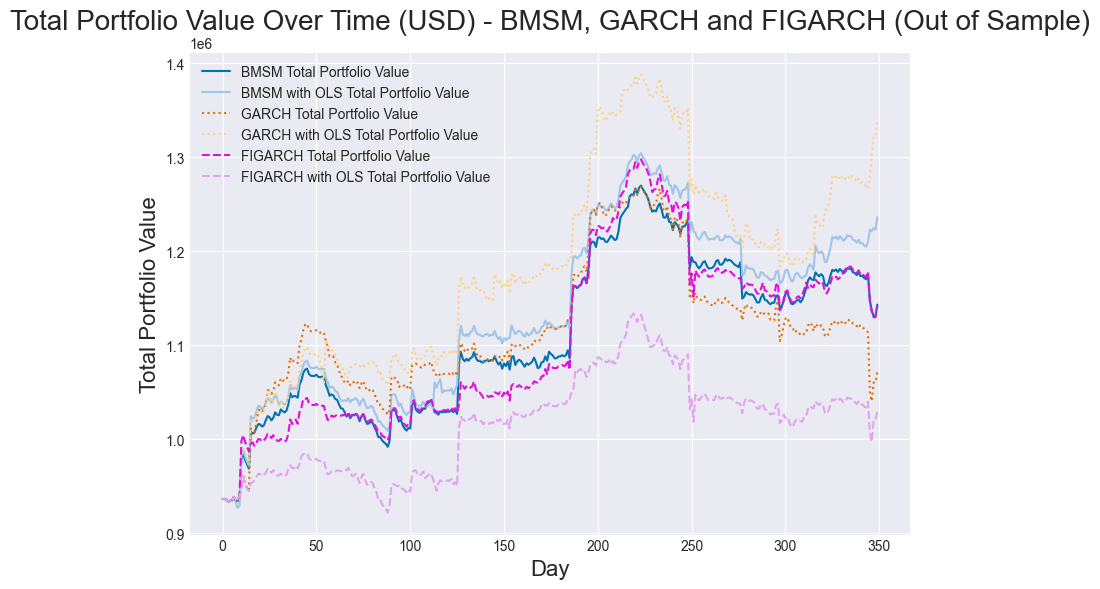

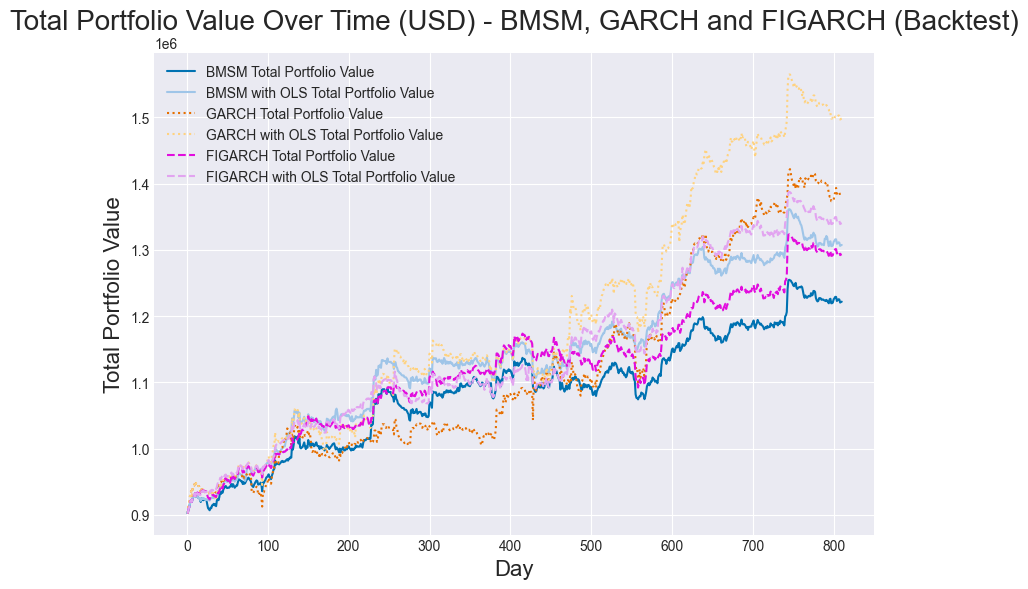

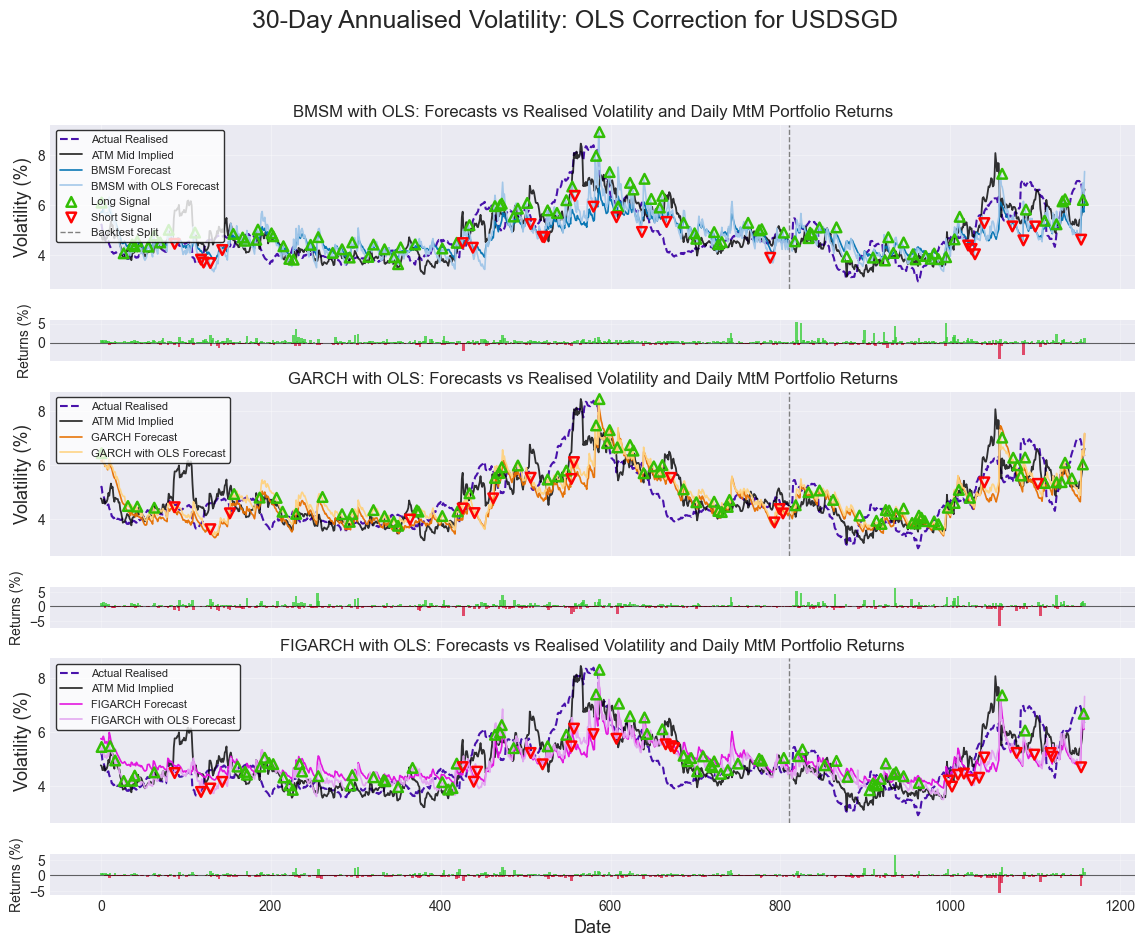

In [6]:
strategy_1 = Compare_Trading_Strategies(
    return_series=daily_log_returns_1, 
    realised_variance_series=realised_variance_1,
    atm_implied_vol_data=implied_vol_data_1,
    vol_smile_data=vol_smile_data_1,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_SGD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_1,
    forecast_horizon=H_1,
    spot_series=spot_curr_test_1,
    overnight_domestic_rate=overn_dom_r_test_1,
    overnight_foreign_rate=overn_for_r_test_1,
    domestic_rate=r_t_test_1,
    foreign_rate=r_b_test_1, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_1 = strategy_1.compare_strategies(verbose = False)

In [8]:
df_1

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.15,0.78,20.00,1.21,-5.52,1.54,9.84%,0.50,0.52,1.22,1.46,0.33%,0.45%,-0.27%,-0.31%,0.51,67.00
BMSM Out of Sample,1.15,0.78,20.00,1.00,-10.93,1.11,15.44%,0.47,0.47,1.39,1.58,0.49%,0.72%,-0.35%,-0.46%,0.52,38.00
BMSM with OLS Backtest,1.05,0.73,20.00,1.46,-4.64,2.28,12.18%,0.50,0.49,1.30,1.51,0.35%,0.44%,-0.27%,-0.29%,0.43,82.00
BMSM with OLS Out of Sample,1.05,0.73,20.00,1.40,-10.61,1.67,22.12%,0.48,0.45,1.50,1.80,0.52%,0.77%,-0.34%,-0.43%,0.46,36.00
GARCH Backtest,1.11,0.75,20.00,1.27,-7.79,1.58,14.17%,0.52,0.54,1.17,1.26,0.41%,0.67%,-0.35%,-0.53%,0.58,69.00
GARCH Out of Sample,1.11,0.75,20.00,0.54,-17.97,0.42,10.21%,0.46,0.46,1.32,1.43,0.50%,0.88%,-0.38%,-0.62%,0.61,31.00
GARCH with OLS Backtest,1.07,0.74,20.00,1.44,-6.55,2.26,17.04%,0.48,0.46,1.42,1.64,0.49%,0.67%,-0.34%,-0.41%,0.40,61.00
GARCH with OLS Out of Sample,1.07,0.74,20.00,1.57,-14.67,1.60,29.22%,0.48,0.46,1.55,1.79,0.62%,0.91%,-0.40%,-0.51%,0.42,35.00
FIGARCH Backtest,1.27,0.79,20.00,1.55,-6.94,1.48,11.81%,0.52,0.55,1.23,1.53,0.32%,0.44%,-0.26%,-0.29%,0.56,61.00
FIGARCH Out of Sample,1.27,0.79,20.00,0.90,-12.93,0.93,15.36%,0.50,0.52,1.26,1.27,0.47%,0.78%,-0.37%,-0.62%,0.62,33.00


# H=91, T=3MO

In [9]:
OPTION_MATURITY_2 = 3 / 12
H_2 = 91 

vol_smile_data_2 = pd.read_csv("usdsgd_vol_smile_3mo_extra.csv").set_index("CalculationDate")
implied_vol_data_2 = pd.DataFrame({
    'Exchange Date': vol_smile_data_2.index, 
    "Bid": vol_smile_data_2['ATM'], 
    "Ask": vol_smile_data_2['ATM'],
    "BidNet": vol_smile_data_2['ATM']})
Data_clean_2 = Clean_Implied_Vols_SGD_with_smile(data=implied_vol_data_2, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdsgd, 
                                align_df2=daily_log_returns_usdsgd, 
                                smile_df=vol_smile_data_2)
implied_vol_data_2, realised_variance_2, daily_log_returns_2, vol_smile_data_2 = Data_clean_2.get_clean_data()

N_2 = len(daily_log_returns_2)
test_align_2 = daily_log_returns_2.iloc[N_2//2:-H_2]
spot_curr_test_2 = align_spots(spot_curr, test_align_2, start_date, end_date)

r_b_2 = pd.read_csv("SOFR_3mo_compounded.csv").set_index("date")
r_t_2 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SORA_3mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_2, r_t_test_2, overn_dom_r_test_2, overn_for_r_test_2= sort_rates(r_b_2, r_t_2, overnight_domestic_rate, test_align_2, overnight_foreign_rate) 
r_b_test_2.ffill(inplace=True)

Estimated parameters: m0=1.247284e+00, sigma_bar=3.110788e-01
Final log-likelihood: -2.421283e+02
Estimated parameters: m0=1.220630e+00, sigma_bar=3.026081e-01
Final log-likelihood: -3.441228e+02


[I 2025-09-03 22:33:25,592] A new study created in memory with name: no-name-9d72f031-2e80-482b-ac1d-d9071c66ea4a
[I 2025-09-03 22:33:26,529] Trial 0 finished with value: 1.3559402758098709 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.3559402758098709.
[I 2025-09-03 22:33:27,442] Trial 1 finished with value: 1.5205218036247754 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.5205218036247754.
[I 2025-09-03 22:33:28,357] Trial 2 finished with value: 1.2000587854291729 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.5205218036247754.
[I 2025-09-03 22:33:29,152] Trial 3 finished with value: 1.482596284052487 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.5205218036247754.
[I 2025-09-03 22:33:30,07

Estimated parameters: omega=0.0005422359622443603, alpha=0.0509, beta=0.9452
Estimated parameters: omega=0.0006278439546422016, alpha=0.0483, beta=0.9462


[I 2025-09-03 22:43:13,786] A new study created in memory with name: no-name-54d8cc97-08f6-40dd-987e-2e29af4f2700
[I 2025-09-03 22:43:14,545] Trial 0 finished with value: 1.722098978745325 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.722098978745325.
[I 2025-09-03 22:43:15,436] Trial 1 finished with value: 1.145437015076271 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.722098978745325.
[I 2025-09-03 22:43:16,457] Trial 2 finished with value: 1.3537535221038235 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.722098978745325.
[I 2025-09-03 22:43:17,142] Trial 3 finished with value: 1.678290864191084 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.722098978745325.
[I 2025-09-03 22:43:17,979] Tri

Estimated parameters: omega=0.01602850765117938, d=0.3177, beta=0.2779
Final log-likelihood = 1668.1033
Estimated parameters: omega=0.016285062808385768, d=0.2822, beta=0.2479
Final log-likelihood = 2896.1939


[I 2025-09-03 22:52:17,822] A new study created in memory with name: no-name-61cb737e-af8e-491a-b29c-1c0a78f1e954
[I 2025-09-03 22:52:18,607] Trial 0 finished with value: 1.0825787712719344 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.0825787712719344.
[I 2025-09-03 22:52:19,371] Trial 1 finished with value: 1.1861431857955742 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.1861431857955742.
[I 2025-09-03 22:52:20,085] Trial 2 finished with value: 1.1834198977329151 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.1861431857955742.
[I 2025-09-03 22:52:20,783] Trial 3 finished with value: 1.1938618114265869 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.1938618114265869.
[I 2025-09-03 22:52:21,5

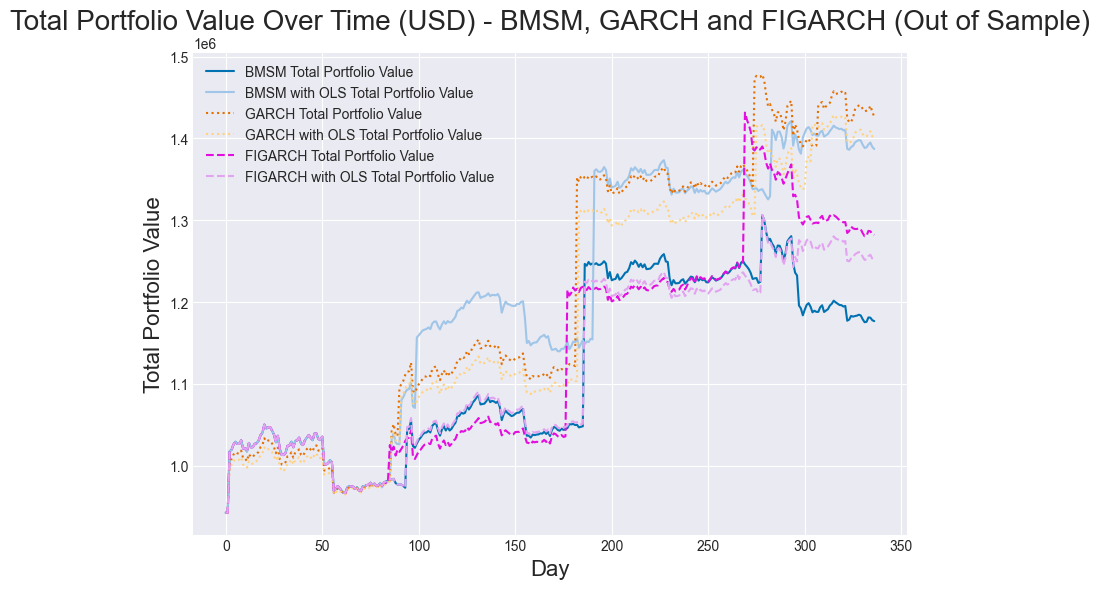

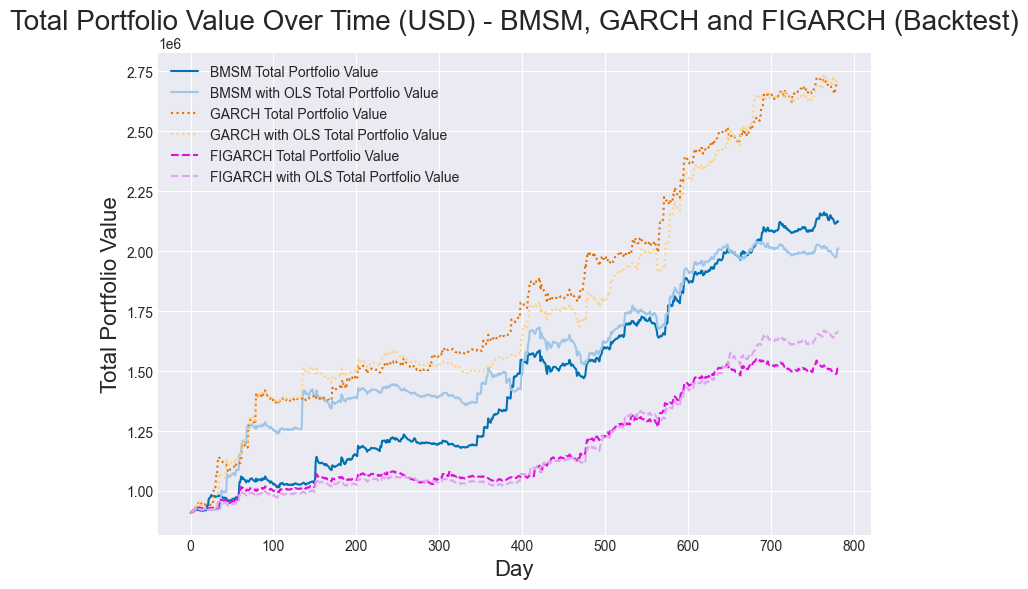

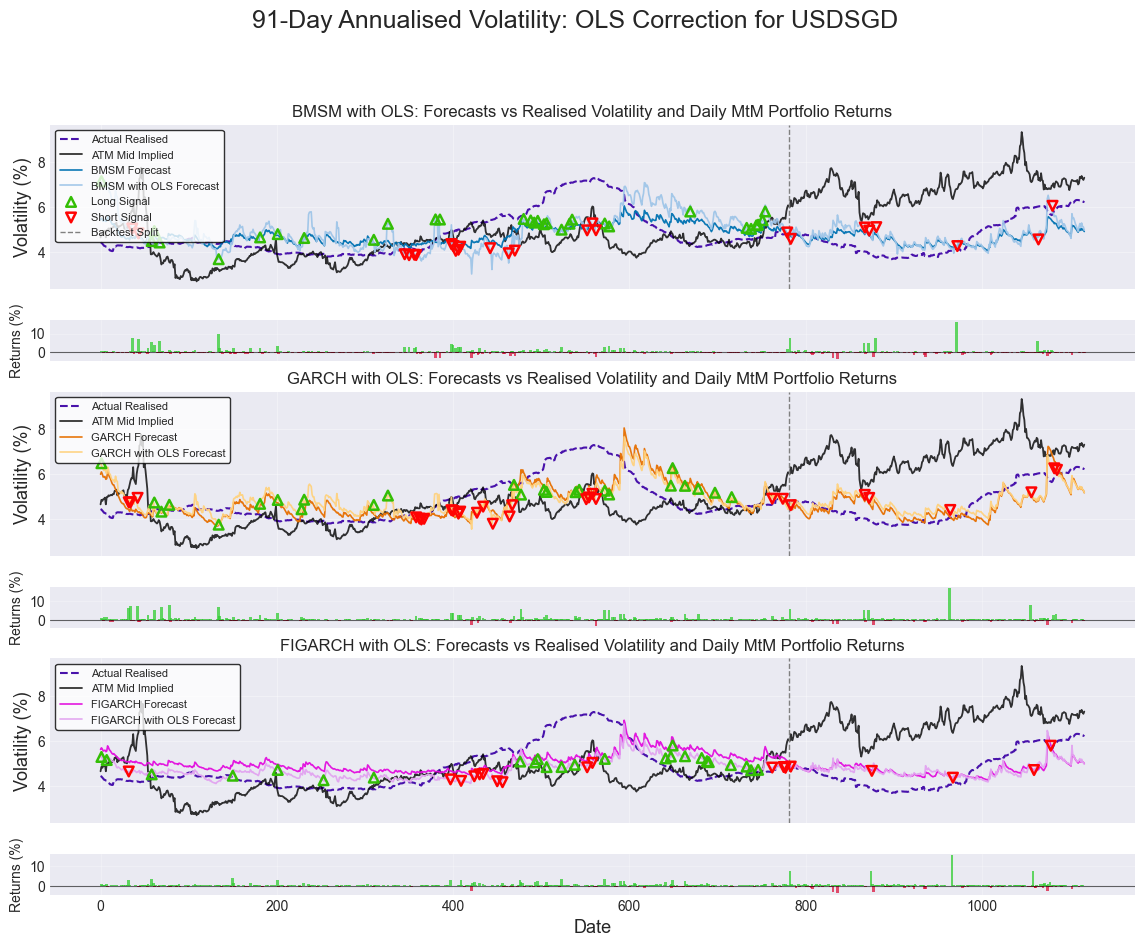

In [10]:
strategy_2 = Compare_Trading_Strategies(
    return_series=daily_log_returns_2, 
    realised_variance_series=realised_variance_2,
    atm_implied_vol_data=implied_vol_data_2,
    vol_smile_data=vol_smile_data_2,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_SGD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_2,
    forecast_horizon=H_2,
    spot_series=spot_curr_test_2,
    overnight_domestic_rate=overn_dom_r_test_2,
    overnight_foreign_rate=overn_for_r_test_2,
    domestic_rate=r_t_test_2,
    foreign_rate=r_b_test_2, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_2 = strategy_2.compare_strategies(verbose = False)

In [11]:
df_2

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.25,0.94,20.00,2.19,-7.35,3.61,31.41%,0.50,0.50,1.71,1.85,0.53%,0.63%,-0.31%,-0.34%,0.26,54.00
BMSM Out of Sample,1.25,0.94,20.00,0.69,-10.00,1.42,18.03%,0.55,0.55,1.03,1.02,0.48%,0.48%,-0.46%,-0.47%,0.01,4.00
BMSM with OLS Backtest,1.25,0.80,20.00,1.78,-9.29,2.66,29.12%,0.48,0.49,1.70,1.84,0.55%,0.64%,-0.32%,-0.35%,0.24,48.00
BMSM with OLS Out of Sample,1.25,0.80,20.00,1.28,-7.95,3.34,33.46%,0.57,0.58,1.15,1.14,0.52%,0.52%,-0.45%,-0.46%,0.04,7.00
GARCH Backtest,1.23,0.79,17.00,2.39,-5.62,6.10,42.02%,0.49,0.51,1.96,2.23,0.60%,0.78%,-0.31%,-0.35%,0.34,41.00
GARCH Out of Sample,1.23,0.79,17.00,1.30,-6.56,4.36,36.28%,0.58,0.59,1.16,1.17,0.52%,0.54%,-0.45%,-0.46%,0.06,6.00
GARCH with OLS Backtest,1.27,0.81,15.00,2.28,-5.94,5.80,42.30%,0.48,0.48,1.98,2.40,0.61%,0.84%,-0.31%,-0.35%,0.37,47.00
GARCH with OLS Out of Sample,1.27,0.81,15.00,1.36,-5.62,4.83,34.25%,0.58,0.58,1.18,1.19,0.49%,0.50%,-0.42%,-0.42%,0.04,7.00
FIGARCH Backtest,1.18,0.85,20.00,1.79,-4.95,3.13,17.73%,0.47,0.49,1.64,1.78,0.42%,0.48%,-0.25%,-0.27%,0.27,27.00
FIGARCH Out of Sample,1.18,0.85,20.00,0.96,-10.55,1.96,25.84%,0.55,0.55,1.15,1.16,0.49%,0.50%,-0.43%,-0.43%,0.01,4.00


# H=182, T=6MO

In [12]:
OPTION_MATURITY_3 = 6 / 12
H_3 = 182

vol_smile_data_3 = pd.read_csv("usdsgd_vol_smile_6mo_extra.csv").set_index("CalculationDate")
implied_vol_data_3 = pd.DataFrame({
    'Exchange Date': vol_smile_data_3.index, 
    "Bid": vol_smile_data_3['ATM'], 
    "Ask": vol_smile_data_3['ATM'],
    "BidNet": vol_smile_data_3['ATM']})
Data_clean_3 = Clean_Implied_Vols_SGD_with_smile(data=implied_vol_data_3, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdsgd, 
                                align_df2=daily_log_returns_usdsgd, 
                                smile_df=vol_smile_data_3)
implied_vol_data_3, realised_variance_3, daily_log_returns_3, vol_smile_data_3 = Data_clean_3.get_clean_data()

N_3 = len(daily_log_returns_3)
test_align_3 = daily_log_returns_3.iloc[N_3//2:-H_3]
spot_curr_test_3 = align_spots(spot_curr, test_align_3, start_date, end_date)

r_b_3 = pd.read_csv("SOFR_6mo_compounded.csv").set_index("date")
r_t_3 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SORA_6mo_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_3, r_t_test_3, overn_dom_r_test_3, overn_for_r_test_3= sort_rates(r_b_3, r_t_3, overnight_domestic_rate, test_align_3, overnight_foreign_rate) 
r_b_test_3.ffill(inplace=True)

Estimated parameters: m0=1.247284e+00, sigma_bar=3.110788e-01
Final log-likelihood: -2.421283e+02
Estimated parameters: m0=1.222375e+00, sigma_bar=3.038406e-01
Final log-likelihood: -3.358341e+02


[I 2025-09-03 23:04:53,405] A new study created in memory with name: no-name-2bb7e34b-38f6-421d-9a91-3fbb72a959a6
[I 2025-09-03 23:04:54,099] Trial 0 finished with value: 1.7048384602666327 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.7048384602666327.
[I 2025-09-03 23:04:54,859] Trial 1 finished with value: 1.815350195833461 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.815350195833461.
[I 2025-09-03 23:04:55,694] Trial 2 finished with value: 1.5014328664186012 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.815350195833461.
[I 2025-09-03 23:04:56,240] Trial 3 finished with value: 1.6968847412543315 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.815350195833461.
[I 2025-09-03 23:04:57,116] 

Estimated parameters: omega=0.0005422359622443603, alpha=0.0509, beta=0.9452
Estimated parameters: omega=0.0006166395366392186, alpha=0.0487, beta=0.9461


[I 2025-09-03 23:12:45,535] A new study created in memory with name: no-name-81efc4c1-d40b-4fb9-a6f2-e1c816ffeebd
[I 2025-09-03 23:12:46,280] Trial 0 finished with value: 1.591041710040207 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.591041710040207.
[I 2025-09-03 23:12:47,106] Trial 1 finished with value: 0.977321309962556 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.591041710040207.
[I 2025-09-03 23:12:47,917] Trial 2 finished with value: 1.6492976786380253 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.6492976786380253.
[I 2025-09-03 23:12:48,552] Trial 3 finished with value: 1.042243881156839 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.6492976786380253.
[I 2025-09-03 23:12:49,288] T

Estimated parameters: omega=0.01602850765117938, d=0.3177, beta=0.2779
Final log-likelihood = 1668.1033
Estimated parameters: omega=0.01609842452982523, d=0.2874, beta=0.2550
Final log-likelihood = 2795.5890


[I 2025-09-03 23:21:17,891] A new study created in memory with name: no-name-03eaa358-1f58-4de0-87f7-b9d0d863fbe5
[I 2025-09-03 23:21:18,583] Trial 0 finished with value: 0.4573127014698176 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.4573127014698176.
[I 2025-09-03 23:21:19,349] Trial 1 finished with value: 1.1782785302202632 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.1782785302202632.
[I 2025-09-03 23:21:20,054] Trial 2 finished with value: 1.072674470264032 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.1782785302202632.
[I 2025-09-03 23:21:20,689] Trial 3 finished with value: 0.8959866849747525 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.1782785302202632.
[I 2025-09-03 23:21:21,49

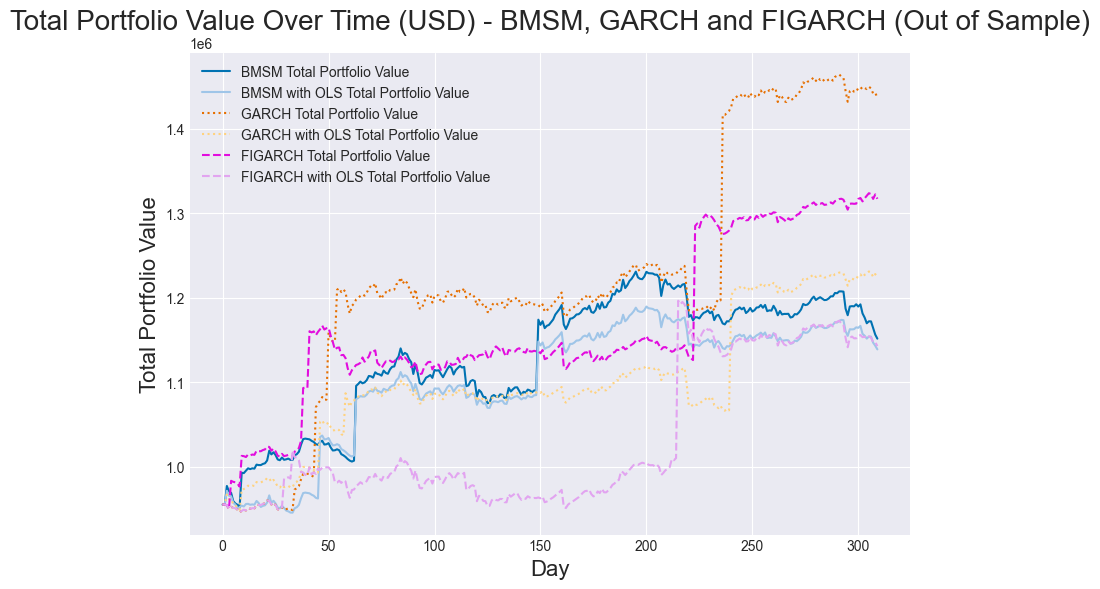

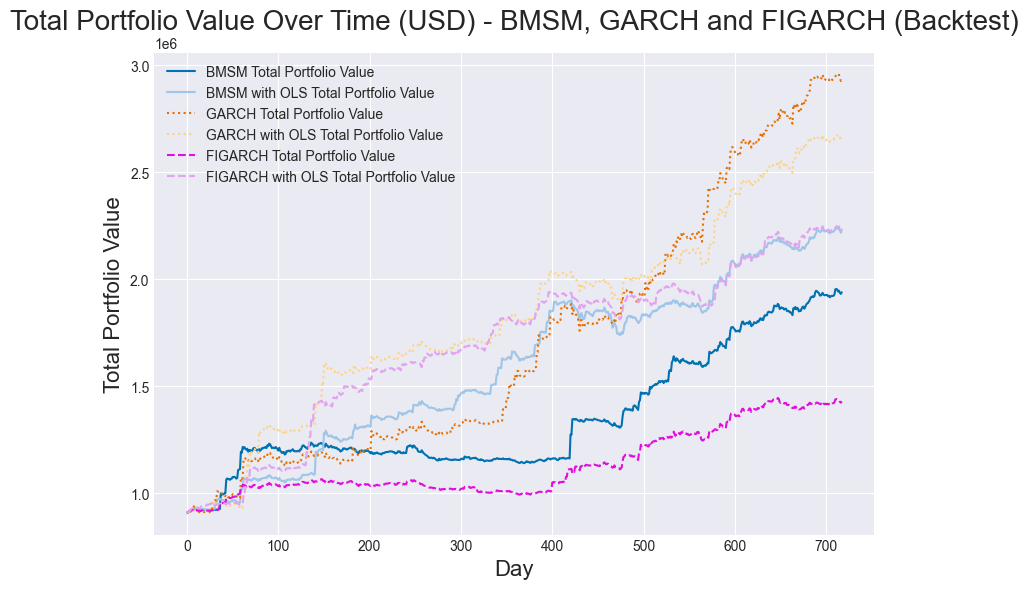

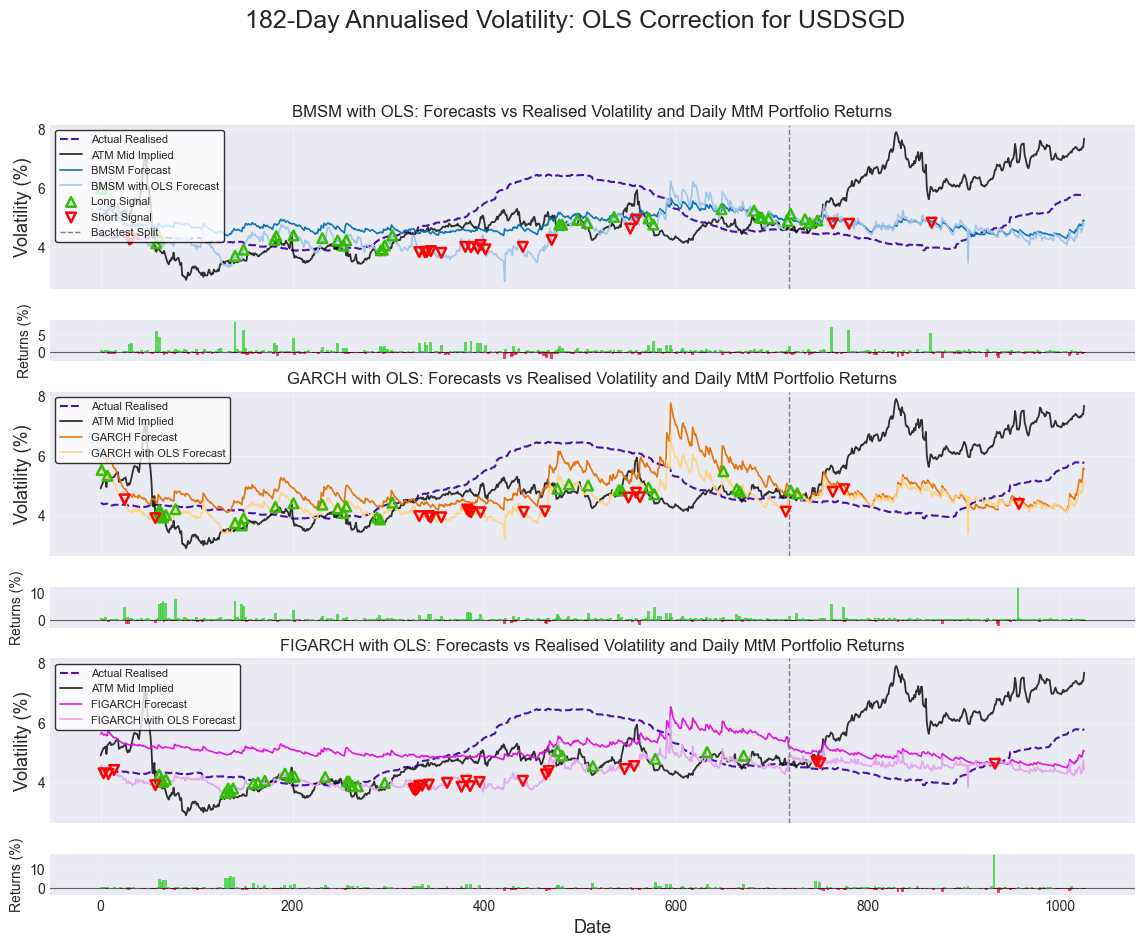

In [13]:
strategy_3 = Compare_Trading_Strategies(
    return_series=daily_log_returns_3, 
    realised_variance_series=realised_variance_3,
    atm_implied_vol_data=implied_vol_data_3,
    vol_smile_data=vol_smile_data_3,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_SGD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_3,
    forecast_horizon=H_3,
    spot_series=spot_curr_test_3,
    overnight_domestic_rate=overn_dom_r_test_3,
    overnight_foreign_rate=overn_for_r_test_3,
    domestic_rate=r_t_test_3,
    foreign_rate=r_b_test_3, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_3 = strategy_3.compare_strategies(verbose = False)

In [14]:
df_3

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.12,0.73,20.00,2.05,-7.77,3.33,30.42%,0.49,0.51,1.77,2.01,0.49%,0.63%,-0.28%,-0.31%,0.37,27.00
BMSM Out of Sample,1.12,0.73,20.00,0.97,-6.45,1.98,16.43%,0.53,0.55,1.13,1.10,0.42%,0.45%,-0.37%,-0.41%,0.18,5.00
BMSM with OLS Backtest,1.07,0.73,15.00,2.48,-8.58,3.60,37.04%,0.52,0.52,1.73,1.97,0.51%,0.62%,-0.29%,-0.32%,0.28,45.00
BMSM with OLS Out of Sample,1.07,0.73,15.00,1.00,-4.26,2.78,15.38%,0.53,0.54,1.17,1.15,0.37%,0.38%,-0.31%,-0.33%,0.14,7.00
GARCH Backtest,1.27,0.86,17.00,2.48,-6.66,6.07,50.78%,0.50,0.52,1.84,1.97,0.69%,0.88%,-0.38%,-0.45%,0.31,41.00
GARCH Out of Sample,1.27,0.86,17.00,1.56,-4.64,6.65,39.40%,0.57,0.59,1.38,1.33,0.47%,0.50%,-0.34%,-0.38%,0.15,5.00
GARCH with OLS Backtest,1.06,0.76,11.00,2.53,-6.89,5.36,45.62%,0.51,0.52,1.90,2.24,0.57%,0.74%,-0.30%,-0.33%,0.33,45.00
GARCH with OLS Out of Sample,1.06,0.76,11.00,1.26,-4.72,3.75,22.31%,0.58,0.60,1.15,1.11,0.34%,0.35%,-0.29%,-0.32%,0.16,5.00
FIGARCH Backtest,1.26,0.93,17.00,1.87,-6.85,2.21,17.16%,0.51,0.53,1.45,1.54,0.36%,0.42%,-0.25%,-0.27%,0.32,30.00
FIGARCH Out of Sample,1.26,0.93,17.00,1.51,-4.99,4.75,29.87%,0.57,0.59,1.29,1.24,0.39%,0.41%,-0.30%,-0.33%,0.12,5.00


# H=364, T=1Y

In [15]:
OPTION_MATURITY_4 = 1
H_4 = 364

vol_smile_data_4 = pd.read_csv("usdsgd_vol_smile_1y_extra.csv").set_index("CalculationDate")
implied_vol_data_4 = pd.DataFrame({
    'Exchange Date': vol_smile_data_4.index, 
    "Bid": vol_smile_data_4['ATM'], 
    "Ask": vol_smile_data_4['ATM'],
    "BidNet": vol_smile_data_4['ATM']})
Data_clean_4 = Clean_Implied_Vols_SGD_with_smile(data=implied_vol_data_4, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdsgd, 
                                align_df2=daily_log_returns_usdsgd, 
                                smile_df=vol_smile_data_4)
implied_vol_data_4, realised_variance_4, daily_log_returns_4, vol_smile_data_4 = Data_clean_4.get_clean_data()

N_4 = len(daily_log_returns_4)
test_align_4 = daily_log_returns_4.iloc[N_4//2:-H_4]
spot_curr_test_4 = align_spots(spot_curr, test_align_4, start_date, end_date)

r_b_4 = pd.read_csv("SOFR_1y_compounded.csv").set_index("date")
r_t_4 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SORA_1y_compounded.csv").set_index("Date")[['rate_pct']]

r_b_test_4, r_t_test_4, overn_dom_r_test_4, overn_for_r_test_4= sort_rates(r_b_4, r_t_4, overnight_domestic_rate, test_align_4, overnight_foreign_rate) 
r_b_test_4.ffill(inplace=True)

Estimated parameters: m0=1.247284e+00, sigma_bar=3.110788e-01
Final log-likelihood: -2.421283e+02
Estimated parameters: m0=1.221646e+00, sigma_bar=3.022316e-01
Final log-likelihood: -2.856906e+02


[I 2025-09-03 23:34:08,106] A new study created in memory with name: no-name-81fcd8b1-720e-4155-abcd-26eaa02c2fc0
[I 2025-09-03 23:34:08,524] Trial 0 finished with value: 1.2008208812484589 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.2008208812484589.
[I 2025-09-03 23:34:09,111] Trial 1 finished with value: 0.7308342222125151 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.2008208812484589.
[I 2025-09-03 23:34:09,570] Trial 2 finished with value: 1.6007451064231255 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.6007451064231255.
[I 2025-09-03 23:34:09,934] Trial 3 finished with value: 1.3955023374952389 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.6007451064231255.
[I 2025-09-03 23:34:10,4

Estimated parameters: omega=0.0005422359622443603, alpha=0.0509, beta=0.9452
Estimated parameters: omega=0.0006337013643858419, alpha=0.0499, beta=0.9446


[I 2025-09-03 23:40:40,975] A new study created in memory with name: no-name-60c66f47-51ee-4858-915d-f672a4a718bf
[I 2025-09-03 23:40:41,509] Trial 0 finished with value: 0.9938225651605757 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.9938225651605757.
[I 2025-09-03 23:40:42,149] Trial 1 finished with value: 1.627935315984065 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.627935315984065.
[I 2025-09-03 23:40:42,675] Trial 2 finished with value: 1.052945265792126 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.627935315984065.
[I 2025-09-03 23:40:43,176] Trial 3 finished with value: 0.6540696227337469 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.627935315984065.
[I 2025-09-03 23:40:43,757] T

Estimated parameters: omega=0.01602850765117938, d=0.3177, beta=0.2779
Final log-likelihood = 1668.1033
Estimated parameters: omega=0.01589817231894883, d=0.2846, beta=0.2475
Final log-likelihood = 2673.3537


[I 2025-09-03 23:48:13,750] A new study created in memory with name: no-name-3d1c6bb9-0360-461b-901f-ed375b8029eb
[I 2025-09-03 23:48:14,340] Trial 0 finished with value: -0.2110837786443124 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: -0.2110837786443124.
[I 2025-09-03 23:48:14,923] Trial 1 finished with value: 1.012937667972541 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.012937667972541.
[I 2025-09-03 23:48:15,449] Trial 2 finished with value: 0.28136928706771913 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.012937667972541.
[I 2025-09-03 23:48:15,992] Trial 3 finished with value: 0.5347446289727769 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.012937667972541.
[I 2025-09-03 23:48:16,87

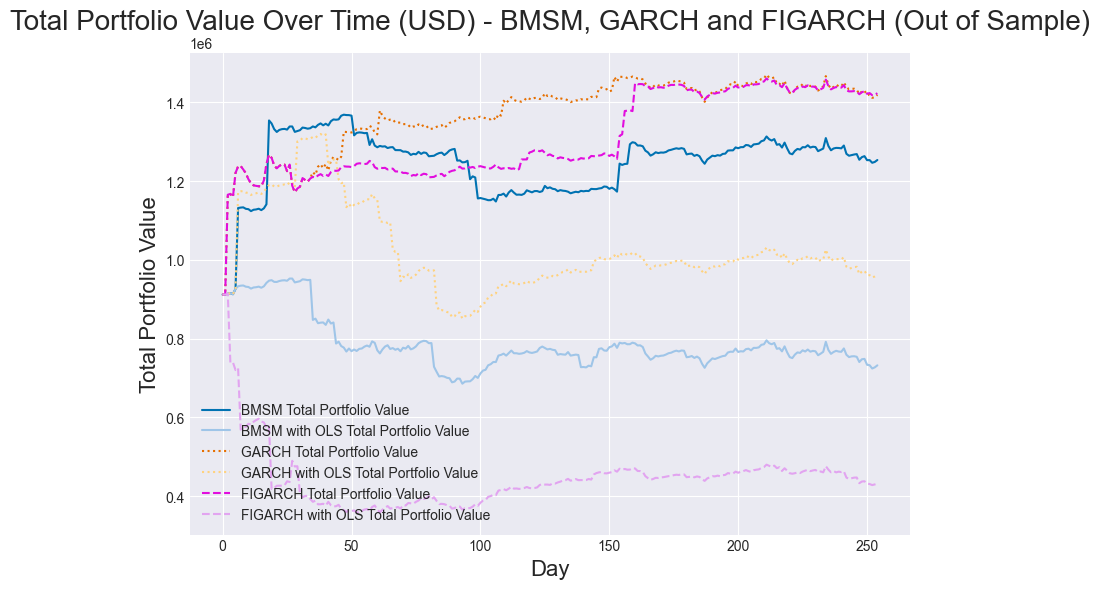

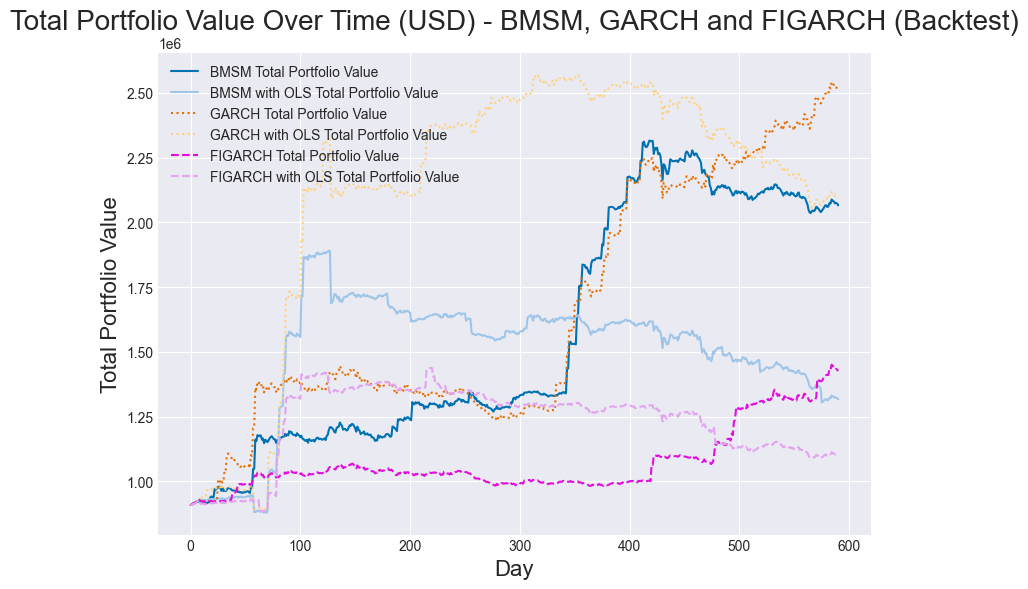

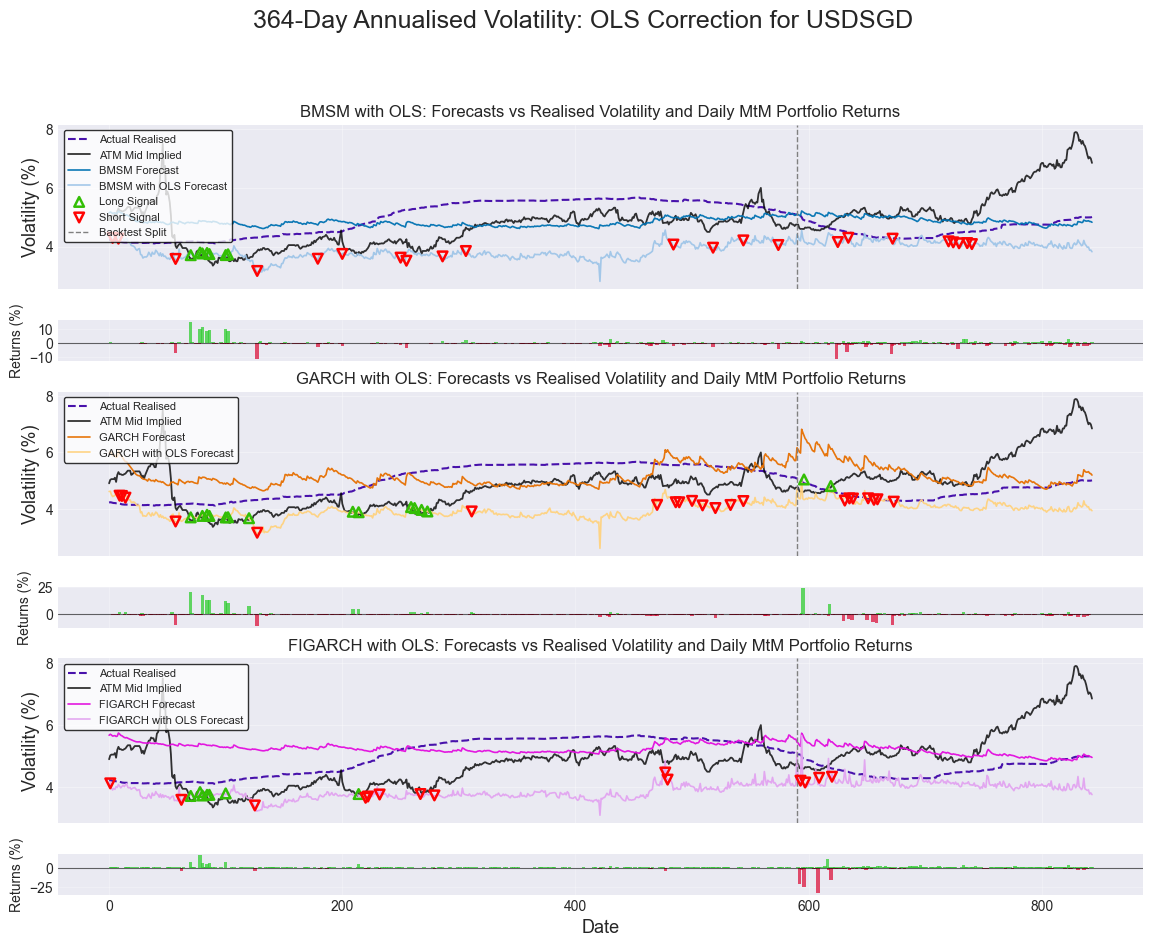

In [19]:
strategy_4 = Compare_Trading_Strategies(
    return_series=daily_log_returns_4, 
    realised_variance_series=realised_variance_4,
    atm_implied_vol_data=implied_vol_data_4,
    vol_smile_data=vol_smile_data_4,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_SGD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_4,
    forecast_horizon=H_4,
    spot_series=spot_curr_test_4,
    overnight_domestic_rate=overn_dom_r_test_4,
    overnight_foreign_rate=overn_for_r_test_4,
    domestic_rate=r_t_test_4,
    foreign_rate=r_b_test_4, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_4 = strategy_4.compare_strategies(verbose = False)

In [21]:
df_4

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.26,0.91,20.00,2.04,-12.06,2.88,41.88%,0.49,0.51,1.78,1.95,0.67%,0.93%,-0.38%,-0.48%,0.40,30.00
BMSM Out of Sample,1.26,0.91,20.00,1.00,-16.10,1.81,36.93%,0.53,0.55,1.28,1.30,0.65%,0.98%,-0.50%,-0.75%,0.48,11.00
BMSM with OLS Backtest,1.03,0.73,20.00,0.69,-30.96,0.50,17.11%,0.55,0.56,1.05,1.06,0.50%,0.68%,-0.48%,-0.65%,0.40,21.00
BMSM with OLS Out of Sample,1.03,0.73,20.00,-1.15,-28.02,-0.86,-19.50%,0.56,0.56,0.60,0.57,0.59%,0.66%,-0.97%,-1.15%,0.20,8.00
GARCH Backtest,1.26,0.98,20.00,2.17,-14.32,3.00,54.10%,0.48,0.50,1.93,1.92,0.81%,0.95%,-0.42%,-0.50%,0.23,31.00
GARCH Out of Sample,1.26,0.98,20.00,1.48,-7.50,5.53,54.78%,0.48,0.50,1.82,1.94,0.79%,1.04%,-0.43%,-0.53%,0.33,8.00
GARCH with OLS Backtest,1.02,0.73,20.00,1.28,-19.98,1.77,42.71%,0.52,0.52,1.57,1.82,0.65%,1.00%,-0.41%,-0.55%,0.44,27.00
GARCH with OLS Out of Sample,1.02,0.73,20.00,0.09,-35.52,0.08,5.43%,0.57,0.57,0.76,0.74,0.66%,0.76%,-0.88%,-1.03%,0.21,9.00
FIGARCH Backtest,1.22,0.94,20.00,1.86,-8.10,2.33,21.15%,0.47,0.49,1.71,1.98,0.44%,0.58%,-0.26%,-0.29%,0.39,17.00
FIGARCH Out of Sample,1.22,0.94,20.00,1.51,-7.50,5.57,55.24%,0.51,0.52,1.87,2.26,0.67%,1.06%,-0.36%,-0.47%,0.48,6.00
